# Phase 12.11: Mall Architecture as Receptacle Correspondence

**Continuation from**: `09_prereg_falsification_tests.ipynb` (Phase 12)

## Theoretical Background

Phase 12 established that:
- Mall = WEST (natural expression of influx from ruling love)
- Mall is a **RECEPTACLE**, not a source
- Functional categories explain 5.2x more variance than cardinal directions (η² = 0.089 vs 0.017)

## Hypothesis: Mall Architecture Corresponds to Receptacle Function

If the mall functions as a spiritual receptacle, its **architectural features** should correspond to RECEIVING:

| Feature | Correspondence | Function |
|---------|---------------|----------|
| Glass walls/ceiling | Lets light (truth) IN | Transparent to influx |
| Water features | Circulation of goods | Flow of natural knowledge |
| Atrium | Open to above | Receiving from higher |
| Escalators/Elevators | Vertical circulation | Pathways for influx |
| Mirrors | Reflection | Truth made manifest |

## Methodology

1. **Filter structured data** → Get locations of type 'mall' or related
2. **Extract source_file** → Link to raw dream text
3. **Search raw text** → Find architectural feature mentions
4. **Analyze co-occurrence** → Do receptacle features cluster in mall contexts?

---

In [1]:
# Standard imports
import json
import re
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency, spearmanr, mannwhitneyu, kruskal, fisher_exact
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
structured_dir = project_root / 'structured'
raw_dir = project_root.parent.parent / 'data' / 'mallworld'

print(f"Notebook dir: {notebook_dir}")
print(f"Structured data: {structured_dir}")
print(f"Raw data: {raw_dir}")
print(f"\nStructured files exist: {structured_dir.exists()}")
print(f"Raw files exist: {raw_dir.exists()}")

Notebook dir: c:\Users\mlf\source\github\structured-data-analysis\projects\mallworld\notebooks
Structured data: c:\Users\mlf\source\github\structured-data-analysis\projects\mallworld\structured
Raw data: c:\Users\mlf\source\github\structured-data-analysis\data\mallworld

Structured files exist: True
Raw files exist: True


In [2]:
# ======================================================================
# LOAD STRUCTURED DATA WITH SOURCE FILE TRACKING
# ======================================================================

json_files = list(structured_dir.glob('mallworld-*.json'))
print(f"Found {len(json_files)} structured extraction files")

dreams = []
skipped = 0
skipped_reasons = Counter()

for f in json_files:
    with open(f, 'r', encoding='utf-8') as file:
        raw = json.load(file)
        
        # Get source file path (for linking to raw data)
        source_file = raw.get('source_file', '')
        
        if 'extraction' in raw:
            ext = raw['extraction']
            classification = ext.get('classification', {})
            
            if classification.get('should_skip_extraction', False):
                skipped += 1
                skipped_reasons[classification.get('skip_reason', 'unknown')] += 1
                continue
            if not classification.get('has_extractable_dream', True):
                skipped += 1
                skipped_reasons['no_extractable_dream'] += 1
                continue
                
            dream_id = f.stem.replace('mallworld-', '')
            dream_data = {
                'dream_id': dream_id,
                'source_file': source_file,
                'source_url': raw.get('source_url', ''),
                'title': raw.get('title', ''),
                'locations': ext.get('locations', []),
                'connections': ext.get('connections', []),
                'interactions': ext.get('interactions', []),
                'meta': ext.get('meta', {}),
                'classification': classification,
            }
            dreams.append(dream_data)

print(f"\nLoaded {len(dreams)} dreams (skipped {skipped} non-dream posts)")
print(f"\nSkip reasons:")
for reason, count in skipped_reasons.most_common():
    print(f"  {reason}: {count}")

Found 3732 structured extraction files

Loaded 2678 dreams (skipped 1054 non-dream posts)

Skip reasons:
  no_extractable_dream: 194
  No dream narrative or phenomenological description provided; author explicitly withholds details.: 2
  No dream narrative or map layout provided; only a vibe-check image.: 1
  No specific dream episode or concrete location descriptions beyond general 'places flow into each other'; primarily a question to others.: 1
  No dream narrative or experienced location is described; only a media reference and subjective vibe.: 1
  Post contains no dream narrative or phenomenological description; it only links to an external thread.: 1
  No specific dream narrative or described dream locations/events; post is speculative/theoretical.: 1
  No direct dream narrative details are provided beyond a general reference to 'mall world bathrooms' and that a TikTok 'accurately shows' them; the linked video content is not included here to extract concrete phenomenological fea

In [3]:
# ======================================================================
# BUILD FLAT DATAFRAMES
# ======================================================================

# Location-level DataFrame
location_rows = []
for d in dreams:
    for loc in d.get('locations', []):
        location_rows.append({
            'dream_id': d['dream_id'],
            'source_file': d['source_file'],
            'location_id': loc.get('location_id'),
            'location_type': loc.get('location_type'),
            'location_name': loc.get('location_name', ''),
            'raw_description': loc.get('qualities', {}).get('raw_description', ''),
            'vertical': loc.get('position', {}).get('vertical'),
            'cardinal': loc.get('position', {}).get('cardinal'),
            'atmosphere': loc.get('qualities', {}).get('atmosphere'),
            'light': loc.get('qualities', {}).get('light'),
            'water_presence': loc.get('qualities', {}).get('water_presence'),
        })

df_locations = pd.DataFrame(location_rows)

# Dream-level DataFrame
df_dreams = pd.DataFrame([{
    'dream_id': d['dream_id'],
    'source_file': d['source_file'],
    'title': d['title'],
    'n_locations': len(d.get('locations', [])),
    'n_connections': len(d.get('connections', [])),
    'n_interactions': len(d.get('interactions', [])),
} for d in dreams])

print(f"Dataset Summary:")
print(f"  Dreams: {len(df_dreams):,}")
print(f"  Locations: {len(df_locations):,}")
print(f"\nLocation types (top 20):")
print(df_locations['location_type'].value_counts().head(20))

Dataset Summary:
  Dreams: 2,678
  Locations: 11,351

Location types (top 20):
location_type
other              2924
mall               1173
mall_store          701
city_street         532
house               445
school              373
hotel               344
beach               260
restaurant          251
neighborhood        187
parking_lot         175
amusement_park      172
waterpark           164
airport             160
forest              151
apartment           144
bathroom_public     144
downtown            141
pool                140
mall_theater        139
Name: count, dtype: int64


In [4]:
# ======================================================================
# IDENTIFY MALL-TYPE LOCATIONS
# ======================================================================

# Mall-related location types (from Phase 10/11 analysis)
MALL_TYPES = [
    'mall', 'shopping_mall', 'shopping_center', 'department_store',
    'mall_store', 'mall_hallway', 'mall_food_court', 'mall_entrance',
    'retail', 'store', 'shop'
]

# Filter for mall-type locations
mall_mask = df_locations['location_type'].str.lower().isin([t.lower() for t in MALL_TYPES])
mall_locs = df_locations[mall_mask].copy()

# Also check location_name for 'mall' mentions
name_mall_mask = df_locations['location_name'].str.lower().str.contains('mall', na=False)
desc_mall_mask = df_locations['raw_description'].str.lower().str.contains('mall', na=False)

# Combine: location_type OR location_name OR description mentions mall
extended_mall_mask = mall_mask | name_mall_mask | desc_mall_mask
extended_mall_locs = df_locations[extended_mall_mask].copy()

print(f"Mall-type locations (strict): {len(mall_locs)}")
print(f"Mall-related locations (extended): {len(extended_mall_locs)}")
print(f"\nLocation types in extended set:")
print(extended_mall_locs['location_type'].value_counts().head(15))

Mall-type locations (strict): 2006
Mall-related locations (extended): 3332

Location types in extended set:
location_type
mall               1173
mall_store          701
other               414
mall_food_court     132
city_street          79
school               58
parking_lot          53
hotel                49
house                40
neighborhood         37
restaurant           36
beach                33
airport              32
mall_theater         30
amusement_park       29
Name: count, dtype: int64


In [5]:
# ======================================================================
# LOAD RAW DREAM TEXT FOR MALL DREAMS
# ======================================================================

def get_raw_content(source_file_path):
    """Load raw dream content from source file."""
    try:
        # Handle both absolute and relative paths
        if source_file_path:
            # Try to extract just the filename
            path = Path(source_file_path)
            filename = path.name
            
            # Look in raw_dir
            raw_path = raw_dir / filename
            if raw_path.exists():
                with open(raw_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    return {
                        'content': data.get('content', ''),
                        'title': data.get('title', ''),
                    }
    except Exception as e:
        pass
    return {'content': '', 'title': ''}

# Get unique dream IDs with mall locations
mall_dream_ids = extended_mall_locs['dream_id'].unique()
mall_dreams_df = df_dreams[df_dreams['dream_id'].isin(mall_dream_ids)].copy()

print(f"Dreams containing mall locations: {len(mall_dreams_df)}")

# Load raw content for these dreams
raw_contents = {}
loaded = 0
empty = 0

for _, row in mall_dreams_df.iterrows():
    raw_data = get_raw_content(row['source_file'])
    if raw_data['content'] and len(raw_data['content']) > 10:
        raw_contents[row['dream_id']] = raw_data
        loaded += 1
    else:
        empty += 1

print(f"\nRaw content loaded: {loaded}")
print(f"Empty/image-only posts: {empty}")

Dreams containing mall locations: 1600

Raw content loaded: 1526
Empty/image-only posts: 74


In [6]:
# ======================================================================
# ARCHITECTURAL FEATURE PATTERNS
# ======================================================================

# Features that correspond to RECEPTACLE function
ARCH_PATTERNS = {
    # Transparency (letting light/truth IN)
    'glass': r'\bglass\b',
    'window': r'\bwindow[s]?\b',
    'skylight': r'\bskylight[s]?\b',
    'transparent': r'\btransparent\b',
    'glass_ceiling': r'\bglass\s+ceiling\b|\bceiling.*glass\b',
    
    # Water (circulation of goods)
    'fountain': r'\bfountain[s]?\b',
    'water_feature': r'\bwater\s*(feature|fall|wall)\b',
    'pool': r'\bpool[s]?\b',
    'aquarium': r'\baquarium[s]?\b',
    
    # Open spaces (receiving from above)
    'atrium': r'\batrium[s]?\b',
    'open_space': r'\bopen\s*(space|area|floor|ceiling)\b',
    'high_ceiling': r'\bhigh\s+ceiling[s]?\b|\bceiling[s]?.*high\b',
    
    # Vertical circulation (influx pathways)
    'escalator': r'\bescalator[s]?\b',
    'elevator': r'\belevator[s]?\b|\blift[s]?\b',
    'stairs': r'\bstair[s]?\b|\bstaircase[s]?\b|\bstairway[s]?\b',
    
    # Light coming in
    'sunlight': r'\bsunlight\b|\bsun\s*light\b',
    'natural_light': r'\bnatural\s+light\b',
    'bright': r'\bbright\b|\bbrightly\s+lit\b',
    
    # Reflection (truth manifest)
    'mirror': r'\bmirror[s]?\b',
    'reflective': r'\breflect\w*\b',
    'shiny': r'\bshin[ey]\b|\bshining\b',
}

# Group into categories
CATEGORY_GROUPS = {
    'TRANSPARENCY': ['glass', 'window', 'skylight', 'transparent', 'glass_ceiling'],
    'WATER': ['fountain', 'water_feature', 'pool', 'aquarium'],
    'OPEN_SPACE': ['atrium', 'open_space', 'high_ceiling'],
    'CIRCULATION': ['escalator', 'elevator', 'stairs'],
    'LIGHT_IN': ['sunlight', 'natural_light', 'bright'],
    'REFLECTION': ['mirror', 'reflective', 'shiny'],
}

print("Architectural feature patterns defined:")
for cat, features in CATEGORY_GROUPS.items():
    print(f"  {cat}: {features}")

Architectural feature patterns defined:
  TRANSPARENCY: ['glass', 'window', 'skylight', 'transparent', 'glass_ceiling']
  WATER: ['fountain', 'water_feature', 'pool', 'aquarium']
  OPEN_SPACE: ['atrium', 'open_space', 'high_ceiling']
  CIRCULATION: ['escalator', 'elevator', 'stairs']
  LIGHT_IN: ['sunlight', 'natural_light', 'bright']
  REFLECTION: ['mirror', 'reflective', 'shiny']


In [7]:
# ======================================================================
# SEARCH RAW TEXTS FOR ARCHITECTURAL FEATURES
# ======================================================================

def search_features(text, patterns):
    """Search text for all patterns, return dict of found features."""
    results = {}
    text_lower = text.lower()
    for name, pattern in patterns.items():
        match = re.search(pattern, text_lower, re.IGNORECASE)
        results[name] = bool(match)
    return results

# Search all mall dream texts
feature_results = []
for dream_id, raw_data in raw_contents.items():
    full_text = f"{raw_data['title']} {raw_data['content']}"
    features = search_features(full_text, ARCH_PATTERNS)
    features['dream_id'] = dream_id
    features['text_length'] = len(raw_data['content'])
    feature_results.append(features)

df_features = pd.DataFrame(feature_results)

print(f"Analyzed {len(df_features)} mall dreams for architectural features")
print(f"\n{'='*60}")
print("ARCHITECTURAL FEATURE FREQUENCIES IN MALL DREAM TEXTS")
print(f"{'='*60}\n")

# Calculate frequencies
feature_cols = [c for c in df_features.columns if c not in ['dream_id', 'text_length']]
feature_counts = {}
for col in feature_cols:
    count = df_features[col].sum()
    pct = count / len(df_features) * 100
    feature_counts[col] = {'count': count, 'pct': pct}

# Sort by count
sorted_features = sorted(feature_counts.items(), key=lambda x: x[1]['count'], reverse=True)

for name, data in sorted_features:
    print(f"{name:20} {data['count']:5}  ({data['pct']:5.1f}%)")

Analyzed 1526 mall dreams for architectural features

ARCHITECTURAL FEATURE FREQUENCIES IN MALL DREAM TEXTS

stairs                 193  ( 12.6%)
elevator               152  ( 10.0%)
window                 148  (  9.7%)
escalator              135  (  8.8%)
glass                  125  (  8.2%)
pool                    91  (  6.0%)
bright                  80  (  5.2%)
fountain                33  (  2.2%)
aquarium                32  (  2.1%)
high_ceiling            31  (  2.0%)
mirror                  26  (  1.7%)
atrium                  24  (  1.6%)
shiny                   20  (  1.3%)
glass_ceiling           17  (  1.1%)
reflective              17  (  1.1%)
water_feature           16  (  1.0%)
skylight                14  (  0.9%)
sunlight                11  (  0.7%)
open_space              10  (  0.7%)
transparent              6  (  0.4%)
natural_light            3  (  0.2%)


In [8]:
# ======================================================================
# CATEGORY-LEVEL ANALYSIS
# ======================================================================

print(f"\n{'='*60}")
print("FEATURE CATEGORY FREQUENCIES (Receptacle Correspondence)")
print(f"{'='*60}\n")

category_results = {}
for category, features in CATEGORY_GROUPS.items():
    # Any feature in category present
    has_category = df_features[[f for f in features if f in df_features.columns]].any(axis=1)
    count = has_category.sum()
    pct = count / len(df_features) * 100
    category_results[category] = {'count': count, 'pct': pct}
    print(f"{category:15} {count:5}  ({pct:5.1f}%)")

# Overall: ANY receptacle feature
any_feature = df_features[feature_cols].any(axis=1)
print(f"\n{'='*40}")
print(f"ANY RECEPTACLE FEATURE: {any_feature.sum()} ({any_feature.sum()/len(df_features)*100:.1f}%)")


FEATURE CATEGORY FREQUENCIES (Receptacle Correspondence)

TRANSPARENCY      237  ( 15.5%)
WATER             156  ( 10.2%)
OPEN_SPACE         60  (  3.9%)
CIRCULATION       371  ( 24.3%)
LIGHT_IN           89  (  5.8%)
REFLECTION         58  (  3.8%)

ANY RECEPTACLE FEATURE: 639 (41.9%)


In [9]:
# ======================================================================
# COMPARISON: MALL vs NON-MALL LOCATIONS
# ======================================================================

print("\nLoading non-mall dreams for comparison...")

# Get dreams WITHOUT mall locations
non_mall_dream_ids = set(df_dreams['dream_id']) - set(mall_dream_ids)
non_mall_dreams_df = df_dreams[df_dreams['dream_id'].isin(non_mall_dream_ids)].copy()

# Sample same number for fair comparison
n_sample = min(len(mall_dreams_df), len(non_mall_dreams_df))
non_mall_sample = non_mall_dreams_df.sample(n=n_sample, random_state=RANDOM_SEED)

# Load raw content for non-mall sample
non_mall_contents = {}
for _, row in non_mall_sample.iterrows():
    raw_data = get_raw_content(row['source_file'])
    if raw_data['content'] and len(raw_data['content']) > 10:
        non_mall_contents[row['dream_id']] = raw_data

print(f"Non-mall dreams loaded: {len(non_mall_contents)}")

# Search for features in non-mall texts
non_mall_results = []
for dream_id, raw_data in non_mall_contents.items():
    full_text = f"{raw_data['title']} {raw_data['content']}"
    features = search_features(full_text, ARCH_PATTERNS)
    features['dream_id'] = dream_id
    features['text_length'] = len(raw_data['content'])
    non_mall_results.append(features)

df_non_mall_features = pd.DataFrame(non_mall_results)

print(f"\n{'='*60}")
print("COMPARISON: MALL vs NON-MALL DREAMS")
print(f"{'='*60}\n")

# Compare each category
comparison_data = []
for category, features in CATEGORY_GROUPS.items():
    valid_features = [f for f in features if f in df_features.columns]
    
    mall_has = df_features[valid_features].any(axis=1).sum()
    mall_pct = mall_has / len(df_features) * 100
    
    non_mall_has = df_non_mall_features[valid_features].any(axis=1).sum()
    non_mall_pct = non_mall_has / len(df_non_mall_features) * 100
    
    # Chi-square test
    ct = [[mall_has, len(df_features) - mall_has],
          [non_mall_has, len(df_non_mall_features) - non_mall_has]]
    
    if min(ct[0]) >= 5 and min(ct[1]) >= 5:
        chi2, p, dof, _ = chi2_contingency(ct)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    else:
        # Use Fisher's exact for small counts
        _, p = fisher_exact(ct)
        chi2 = np.nan
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    
    comparison_data.append({
        'Category': category,
        'Mall %': mall_pct,
        'Non-Mall %': non_mall_pct,
        'Difference': mall_pct - non_mall_pct,
        'p-value': p,
        'Sig': sig
    })

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))


Loading non-mall dreams for comparison...
Non-mall dreams loaded: 1035

COMPARISON: MALL vs NON-MALL DREAMS

    Category    Mall %  Non-Mall %  Difference      p-value Sig
TRANSPARENCY 15.530799   11.787440    3.743360 8.801188e-03  **
       WATER 10.222805    7.922705    2.300099 5.769315e-02    
  OPEN_SPACE  3.931848    2.222222    1.709626 2.238147e-02   *
 CIRCULATION 24.311927   15.555556    8.756371 1.092933e-07 ***
    LIGHT_IN  5.832241    3.285024    2.547217 4.180845e-03  **
  REFLECTION  3.800786    2.898551    0.902236 2.629235e-01    


In [10]:
# ======================================================================
# SYNTHESIS: RECEPTACLE CORRESPONDENCE VALIDATION
# ======================================================================

print(f"\n{'='*70}")
print("PHASE 12.11 SYNTHESIS: Mall Architecture as Receptacle Correspondence")
print(f"{'='*70}\n")

# Calculate overall comparison
mall_any = df_features[feature_cols].any(axis=1).sum() / len(df_features) * 100
non_mall_any = df_non_mall_features[feature_cols].any(axis=1).sum() / len(df_non_mall_features) * 100

print(f"Mall dreams with ANY receptacle feature:     {mall_any:.1f}%")
print(f"Non-mall dreams with ANY receptacle feature: {non_mall_any:.1f}%")
print(f"Difference: +{mall_any - non_mall_any:.1f}%")

print(f"\n{'='*40}")
print("INTERPRETATION")
print(f"{'='*40}")
print("""
If mall architectural features cluster significantly MORE in mall dreams:
→ This supports the correspondence hypothesis: mall ARCHITECTURE 
  reflects its FUNCTION as a spiritual receptacle.

The mall's glass, water, open spaces, and escalators are not arbitrary
design choices but correspond to its role in receiving and circulating
goods from the ruling love (East) into natural expression (West).

Glass = transparent to influx (truth/light enters)
Water = circulation of natural goods  
Atrium = open to receive from above
Escalators = vertical pathways for influx
""")


PHASE 12.11 SYNTHESIS: Mall Architecture as Receptacle Correspondence

Mall dreams with ANY receptacle feature:     41.9%
Non-mall dreams with ANY receptacle feature: 32.9%
Difference: +8.9%

INTERPRETATION

If mall architectural features cluster significantly MORE in mall dreams:
→ This supports the correspondence hypothesis: mall ARCHITECTURE 
  reflects its FUNCTION as a spiritual receptacle.

The mall's glass, water, open spaces, and escalators are not arbitrary
design choices but correspond to its role in receiving and circulating
goods from the ruling love (East) into natural expression (West).

Glass = transparent to influx (truth/light enters)
Water = circulation of natural goods  
Atrium = open to receive from above
Escalators = vertical pathways for influx



In [11]:
# Final Statistical Summary
print("""
======================================================================
PHASE 13: ARCHITECTURAL CORRESPONDENCE TEST - FINAL STATISTICS
======================================================================

METHODOLOGY:
- Filter structured data for mall-type locations first
- Use source_file property to link to raw dream text
- Search architectural patterns in mall context specifically
- Compare mall vs non-mall dreams

SAMPLE SIZES:
- Mall dreams analyzed: 1,526
- Non-mall dreams analyzed: 1,035

KEY FINDINGS:

1. CIRCULATION (escalators, elevators, stairs):
   Mall:     24.3%
   Non-Mall: 15.6%
   Δ = +8.8%, p < 0.0001 (χ² highly significant ***)
   
2. TRANSPARENCY (glass, windows, skylights):
   Mall:     15.5%
   Non-Mall: 11.8%
   Δ = +3.7%, p = 0.009 (**)

3. LIGHT_IN (sunlight, natural light, bright):
   Mall:     5.8%
   Non-Mall: 3.3%
   Δ = +2.5%, p = 0.004 (**)

4. OPEN_SPACE (atrium, high ceiling):
   Mall:     3.9%
   Non-Mall: 2.2%
   Δ = +1.7%, p = 0.02 (*)

5. WATER (fountain, pool, aquarium):
   Mall:     10.2%
   Non-Mall: 7.9%
   Δ = +2.3%, p = 0.058 (trend)

6. REFLECTION (mirror, shiny):
   Mall:     3.8%
   Non-Mall: 2.9%
   Δ = +0.9%, p = 0.26 (ns)

ANY RECEPTACLE FEATURE:
   Mall:     41.9%
   Non-Mall: 32.9%
   Δ = +9.0%

======================================================================
INTERPRETATION
======================================================================

Mall dreams show SIGNIFICANTLY higher frequencies of:
- CIRCULATION features (+8.8%, p < 0.0001) - vertical influx pathways
- TRANSPARENCY features (+3.7%, p = 0.009) - receptive to truth/light
- LIGHT_IN features (+2.5%, p = 0.004) - receiving from above
- OPEN_SPACE features (+1.7%, p = 0.02) - capacity to receive

This is consistent with the correspondence hypothesis:
→ Mall architecture corresponds to RECEPTACLE function (WEST)
→ The structural features facilitate RECEIVING and CIRCULATING
→ Not arbitrary design but ontological correspondence

The 41.9% vs 32.9% overall rate (+9.0%) demonstrates that mall dreams
spontaneously generate MORE receptacle-type architectural imagery than
non-mall dreams - consistent with the framework prediction.
""")


PHASE 13: ARCHITECTURAL CORRESPONDENCE TEST - FINAL STATISTICS

METHODOLOGY:
- Filter structured data for mall-type locations first
- Use source_file property to link to raw dream text
- Search architectural patterns in mall context specifically
- Compare mall vs non-mall dreams

SAMPLE SIZES:
- Mall dreams analyzed: 1,526
- Non-mall dreams analyzed: 1,035

KEY FINDINGS:

1. CIRCULATION (escalators, elevators, stairs):
   Mall:     24.3%
   Non-Mall: 15.6%
   Δ = +8.8%, p < 0.0001 (χ² highly significant ***)

2. TRANSPARENCY (glass, windows, skylights):
   Mall:     15.5%
   Non-Mall: 11.8%
   Δ = +3.7%, p = 0.009 (**)

3. LIGHT_IN (sunlight, natural light, bright):
   Mall:     5.8%
   Non-Mall: 3.3%
   Δ = +2.5%, p = 0.004 (**)

4. OPEN_SPACE (atrium, high ceiling):
   Mall:     3.9%
   Non-Mall: 2.2%
   Δ = +1.7%, p = 0.02 (*)

5. WATER (fountain, pool, aquarium):
   Mall:     10.2%
   Non-Mall: 7.9%
   Δ = +2.3%, p = 0.058 (trend)

6. REFLECTION (mirror, shiny):
   Mall:     3.8%


# Phase 13b: Building Type Profiles

The previous analysis was flawed - comparing "mall vs non-mall" doesn't confirm anything.
The proper test is to build **profiles for EACH building type** and see if they DIFFER
in ways consistent with correspondence theory.

**Methodology:**
1. For each building type in the structured data
2. Find all dreams containing that building type
3. Load raw text via source_file
4. Search for architectural features + metals
5. Build a feature profile for that building type
6. Compare profiles across building types

**Swedenborgian Metal Correspondences:**
- Gold = celestial good (love)
- Silver = spiritual truth (wisdom)
- Brass/Bronze = natural good
- Iron = natural truth (often harsh)
- Copper = natural good in outward form
- Steel = rational truth applied

If correspondences are real, different building types should show DIFFERENT feature profiles.

In [12]:
# Expanded feature patterns including metals
EXPANDED_PATTERNS = {
    # Architectural features
    'glass': r'\bglass\b',
    'window': r'\bwindow[s]?\b',
    'skylight': r'\bskylight[s]?\b',
    'fountain': r'\bfountain[s]?\b',
    'water_feature': r'\bwater\s*feature[s]?\b',
    'pool': r'\bpool[s]?\b',
    'aquarium': r'\baquarium[s]?\b',
    'atrium': r'\batrium[s]?\b',
    'escalator': r'\bescalator[s]?\b',
    'elevator': r'\belevator[s]?\b',
    'stairs': r'\bstair[s]?\b',
    'mirror': r'\bmirror[s]?\b',
    'high_ceiling': r'\b(high|tall|vaulted)\s+(ceiling[s]?|roof[s]?)\b',
    'bright': r'\bbright\b',
    'natural_light': r'\bnatural\s+light\b',
    'sunlight': r'\bsunlight\b',
    'tile': r'\btile[sd]?\b',
    'marble': r'\bmarble\b',
    'concrete': r'\bconcrete\b',
    'brick': r'\bbrick[s]?\b',
    'wood': r'\bwood(en)?\b',
    'carpet': r'\bcarpet(ed|ing)?\b',
    'neon': r'\bneon\b',
    'fluorescent': r'\bfluorescent\b',
    
    # Metals (Swedenborgian correspondences)
    'gold': r'\bgold(en)?\b',
    'silver': r'\bsilver\b',
    'brass': r'\bbrass\b',
    'bronze': r'\bbronze\b',
    'iron': r'\biron\b',
    'copper': r'\bcopper\b',
    'steel': r'\bsteel\b',
    'chrome': r'\bchrome\b',
    'metal': r'\bmetal(lic)?\b',
    
    # Additional structural
    'column': r'\bcolumn[s]?\b',
    'pillar': r'\bpillar[s]?\b',
    'arch': r'\barch(es|way[s]?)?\b',
    'dome': r'\bdome[sd]?\b',
    'balcony': r'\bbalcon(y|ies)\b',
    'courtyard': r'\bcourtyard[s]?\b',
    'hallway': r'\bhallway[s]?\b',
    'corridor': r'\bcorridor[s]?\b',
}

# Categorization
FEATURE_CATEGORIES = {
    'TRANSPARENCY': ['glass', 'window', 'skylight'],
    'WATER': ['fountain', 'water_feature', 'pool', 'aquarium'],
    'VERTICAL_CIRC': ['escalator', 'elevator', 'stairs'],
    'OPEN_SPACE': ['atrium', 'high_ceiling', 'courtyard'],
    'LIGHT': ['bright', 'natural_light', 'sunlight', 'neon', 'fluorescent'],
    'REFLECTION': ['mirror', 'chrome'],
    'METALS': ['gold', 'silver', 'brass', 'bronze', 'iron', 'copper', 'steel', 'chrome', 'metal'],
    'FLOORING': ['tile', 'marble', 'concrete', 'brick', 'wood', 'carpet'],
    'STRUCTURE': ['column', 'pillar', 'arch', 'dome', 'balcony', 'hallway', 'corridor'],
}

print(f"Expanded patterns: {len(EXPANDED_PATTERNS)} features")
print(f"Categories: {len(FEATURE_CATEGORIES)}")
for cat, feats in FEATURE_CATEGORIES.items():
    print(f"  {cat}: {feats}")

Expanded patterns: 41 features
Categories: 9
  TRANSPARENCY: ['glass', 'window', 'skylight']
  WATER: ['fountain', 'water_feature', 'pool', 'aquarium']
  VERTICAL_CIRC: ['escalator', 'elevator', 'stairs']
  OPEN_SPACE: ['atrium', 'high_ceiling', 'courtyard']
  LIGHT: ['bright', 'natural_light', 'sunlight', 'neon', 'fluorescent']
  REFLECTION: ['mirror', 'chrome']
  METALS: ['gold', 'silver', 'brass', 'bronze', 'iron', 'copper', 'steel', 'chrome', 'metal']
  FLOORING: ['tile', 'marble', 'concrete', 'brick', 'wood', 'carpet']
  STRUCTURE: ['column', 'pillar', 'arch', 'dome', 'balcony', 'hallway', 'corridor']


In [13]:
# Get all building types with sufficient sample size
location_type_counts = df_locations['location_type'].value_counts()

# Filter to building types with at least 50 instances
MIN_LOCATIONS = 50
valid_types = location_type_counts[location_type_counts >= MIN_LOCATIONS].index.tolist()

print(f"Building types with >= {MIN_LOCATIONS} locations: {len(valid_types)}")
print("\nLocation type distribution:")
for lt in valid_types[:25]:  # Top 25
    count = location_type_counts[lt]
    print(f"  {lt:25s} {count:5d}")

Building types with >= 50 locations: 44

Location type distribution:
  other                      2924
  mall                       1173
  mall_store                  701
  city_street                 532
  house                       445
  school                      373
  hotel                       344
  beach                       260
  restaurant                  251
  neighborhood                187
  parking_lot                 175
  amusement_park              172
  waterpark                   164
  airport                     160
  forest                      151
  apartment                   144
  bathroom_public             144
  downtown                    141
  pool                        140
  mall_theater                139
  theater                     136
  mall_food_court             132
  mountain                    104
  parking_structure            95
  hotel_room                   93


In [14]:
# Build profiles for each building type
def get_dreams_by_location_type(loc_type):
    """Get unique dream IDs containing a specific location type."""
    mask = df_locations['location_type'] == loc_type
    return df_locations[mask]['dream_id'].unique()

def load_raw_content_for_dreams(dream_ids, max_dreams=None):
    """Load raw content for a set of dream IDs via source_file mapping."""
    contents = {}
    dreams_with_content = df_dreams[df_dreams['dream_id'].isin(dream_ids)]
    
    if max_dreams:
        dreams_with_content = dreams_with_content.head(max_dreams)
    
    for _, row in dreams_with_content.iterrows():
        source_file = row.get('source_file')
        if not source_file:
            continue
            
        raw_path = raw_dir / source_file
        if raw_path.exists():
            try:
                with open(raw_path, 'r', encoding='utf-8') as f:
                    raw = json.load(f)
                    content = raw.get('content', '')
                    if content and len(content.strip()) > 10:
                        contents[row['dream_id']] = content.lower()
            except:
                pass
    
    return contents

def search_features_in_texts(contents, patterns):
    """Search for features in text contents."""
    results = {feat: 0 for feat in patterns}
    
    for text in contents.values():
        for feat, pattern in patterns.items():
            if re.search(pattern, text, re.IGNORECASE):
                results[feat] += 1
    
    n = len(contents)
    return {feat: (count, count/n*100 if n > 0 else 0) for feat, (count) in 
            [(f, results[f]) for f in results]}

print("Functions defined. Ready to build profiles.")

Functions defined. Ready to build profiles.


In [15]:
# Build profiles for all valid building types
# This will take a while - loading raw content for each type

building_profiles = {}
MIN_DREAMS = 30  # Minimum dreams to include in analysis

print("Building profiles for each location type...")
print("=" * 70)

for i, loc_type in enumerate(valid_types):
    # Get dreams with this location type
    dream_ids = get_dreams_by_location_type(loc_type)
    
    # Load raw content
    contents = load_raw_content_for_dreams(dream_ids)
    
    if len(contents) < MIN_DREAMS:
        continue
    
    # Search for features
    feature_results = {}
    for feat, pattern in EXPANDED_PATTERNS.items():
        count = sum(1 for text in contents.values() if re.search(pattern, text, re.IGNORECASE))
        feature_results[feat] = {
            'count': count,
            'pct': count / len(contents) * 100
        }
    
    # Store profile
    building_profiles[loc_type] = {
        'n_dreams': len(contents),
        'n_locations': location_type_counts[loc_type],
        'features': feature_results
    }
    
    if (i + 1) % 5 == 0:
        print(f"  Processed {i+1}/{len(valid_types)} types...")

print(f"\nProfiles built for {len(building_profiles)} building types")

Building profiles for each location type...
  Processed 5/44 types...
  Processed 10/44 types...
  Processed 15/44 types...
  Processed 20/44 types...
  Processed 25/44 types...
  Processed 30/44 types...
  Processed 35/44 types...
  Processed 40/44 types...

Profiles built for 44 building types


In [16]:
# Display feature profiles by building type
def display_building_profile(loc_type, profile, top_n=15):
    """Display the architectural profile for a building type."""
    print(f"\n{'=' * 70}")
    print(f"BUILDING TYPE: {loc_type.upper()}")
    print(f"Dreams analyzed: {profile['n_dreams']}, Locations: {profile['n_locations']}")
    print(f"{'=' * 70}")
    
    # Sort features by percentage
    sorted_feats = sorted(profile['features'].items(), 
                          key=lambda x: x[1]['pct'], 
                          reverse=True)
    
    print(f"\n{'Feature':<20} {'Count':>8} {'%':>8}")
    print("-" * 40)
    
    for feat, data in sorted_feats[:top_n]:
        if data['count'] > 0:
            print(f"{feat:<20} {data['count']:>8} {data['pct']:>7.1f}%")

# Display profiles for key building types
key_types = ['mall', 'hotel', 'school', 'house', 'restaurant', 'airport', 
             'beach', 'forest', 'church', 'basement', 'parking_lot', 'hospital']

for lt in key_types:
    if lt in building_profiles:
        display_building_profile(lt, building_profiles[lt])


BUILDING TYPE: MALL
Dreams analyzed: 972, Locations: 1173

Feature                 Count        %
----------------------------------------
escalator                 120    12.3%
elevator                  106    10.9%
hallway                    99    10.2%
glass                      93     9.6%
stairs                     91     9.4%
window                     90     9.3%
wood                       52     5.3%
corridor                   51     5.2%
bright                     49     5.0%
pool                       47     4.8%
metal                      43     4.4%
neon                       39     4.0%
gold                       35     3.6%
carpet                     33     3.4%
tile                       32     3.3%

BUILDING TYPE: HOTEL
Dreams analyzed: 287, Locations: 344

Feature                 Count        %
----------------------------------------
elevator                   75    26.1%
hallway                    55    19.2%
pool                       47    16.4%
window            

In [17]:
# Create comparison DataFrame across all building types
# Rows = building types, Columns = feature percentages

profile_data = []
for loc_type, profile in building_profiles.items():
    row = {'location_type': loc_type, 'n_dreams': profile['n_dreams']}
    for feat, data in profile['features'].items():
        row[feat] = data['pct']
    profile_data.append(row)

df_profiles = pd.DataFrame(profile_data)
df_profiles = df_profiles.set_index('location_type')

print(f"Profile matrix: {df_profiles.shape[0]} building types × {df_profiles.shape[1]-1} features")
print(f"\nBuilding types included:")
for lt in df_profiles.index:
    n = building_profiles[lt]['n_dreams']
    print(f"  {lt}: {n} dreams")

Profile matrix: 44 building types × 41 features

Building types included:
  other: 1392 dreams
  mall: 972 dreams
  mall_store: 465 dreams
  city_street: 422 dreams
  house: 358 dreams
  school: 296 dreams
  hotel: 287 dreams
  beach: 215 dreams
  restaurant: 202 dreams
  neighborhood: 158 dreams
  parking_lot: 155 dreams
  amusement_park: 136 dreams
  waterpark: 154 dreams
  airport: 150 dreams
  forest: 137 dreams
  apartment: 122 dreams
  bathroom_public: 129 dreams
  downtown: 123 dreams
  pool: 113 dreams
  mall_theater: 124 dreams
  theater: 122 dreams
  mall_food_court: 125 dreams
  mountain: 90 dreams
  parking_structure: 87 dreams
  hotel_room: 84 dreams
  mansion: 79 dreams
  train_station: 83 dreams
  mall_arcade: 76 dreams
  office: 78 dreams
  underground: 78 dreams
  library: 61 dreams
  hospital: 71 dreams
  bathroom: 68 dreams
  casino: 67 dreams
  school_classroom: 65 dreams
  hotel_lobby: 64 dreams
  warehouse: 63 dreams
  basement: 59 dreams
  cave: 49 dreams
  unspe

In [18]:
# Metals analysis across building types
metal_features = ['gold', 'silver', 'brass', 'bronze', 'iron', 'copper', 'steel', 'chrome', 'metal']

print("=" * 80)
print("METAL MENTIONS BY BUILDING TYPE")
print("=" * 80)
print(f"\n{'Building Type':<20}", end="")
for m in metal_features:
    print(f"{m:>8}", end="")
print(f"{'TOTAL':>10}")
print("-" * 100)

metal_totals = {lt: 0 for lt in df_profiles.index}

for lt in df_profiles.index:
    n = building_profiles[lt]['n_dreams']
    print(f"{lt:<20}", end="")
    row_total = 0
    for m in metal_features:
        val = df_profiles.loc[lt, m] if m in df_profiles.columns else 0
        print(f"{val:>7.1f}%", end="")
        row_total += val
    metal_totals[lt] = row_total
    print(f"{row_total:>9.1f}%")

# Sort by total metal mentions
print("\n" + "=" * 80)
print("RANKED BY TOTAL METAL MENTIONS")
print("=" * 80)
sorted_metals = sorted(metal_totals.items(), key=lambda x: x[1], reverse=True)
for lt, total in sorted_metals[:15]:
    n = building_profiles[lt]['n_dreams']
    print(f"  {lt:<25} {total:>6.1f}% total metals  (n={n})")

METAL MENTIONS BY BUILDING TYPE

Building Type           gold  silver   brass  bronze    iron  copper   steel  chrome   metal     TOTAL
----------------------------------------------------------------------------------------------------
other                   3.4%    1.0%    0.3%    0.3%    0.4%    0.1%    0.6%    0.1%    4.7%     11.1%
mall                    3.6%    1.0%    0.3%    0.3%    0.4%    0.2%    0.4%    0.2%    4.4%     10.9%
mall_store              4.9%    0.9%    0.4%    0.2%    0.4%    0.0%    0.6%    0.2%    4.7%     12.5%
city_street             3.1%    1.2%    0.5%    0.7%    0.5%    0.2%    0.2%    0.0%    4.3%     10.7%
house                   2.5%    0.3%    0.0%    0.3%    0.0%    0.3%    1.1%    0.3%    3.6%      8.4%
school                  1.4%    0.0%    0.0%    0.3%    0.0%    0.3%    1.4%    0.0%    5.4%      8.8%
hotel                   8.7%    0.0%    0.3%    0.3%    0.3%    0.3%    1.0%    0.0%    3.1%     14.3%
beach                   4.2%    0.9%    0.

In [19]:
# Category-level comparison across building types
print("=" * 90)
print("FEATURE CATEGORY COMPARISON ACROSS BUILDING TYPES")
print("=" * 90)

# Calculate category totals for each building type
category_scores = {}
for lt in df_profiles.index:
    category_scores[lt] = {}
    for cat, feats in FEATURE_CATEGORIES.items():
        total = sum(df_profiles.loc[lt, f] for f in feats if f in df_profiles.columns)
        category_scores[lt][cat] = total

# Create category DataFrame
df_categories = pd.DataFrame(category_scores).T
df_categories['n_dreams'] = [building_profiles[lt]['n_dreams'] for lt in df_categories.index]

# Display
print(f"\n{'Building Type':<20}", end="")
for cat in FEATURE_CATEGORIES.keys():
    print(f"{cat[:10]:>12}", end="")
print()
print("-" * 130)

for lt in df_categories.index:
    print(f"{lt:<20}", end="")
    for cat in FEATURE_CATEGORIES.keys():
        val = df_categories.loc[lt, cat]
        print(f"{val:>11.1f}%", end="")
    print()

FEATURE CATEGORY COMPARISON ACROSS BUILDING TYPES

Building Type         TRANSPAREN       WATER  VERTICAL_C  OPEN_SPACE       LIGHT  REFLECTION      METALS    FLOORING   STRUCTURE
----------------------------------------------------------------------------------------------------------------------------------
other                      21.0%       11.5%       27.4%        3.3%        8.5%        2.3%       11.1%       21.6%       21.5%
mall                       20.1%       10.2%       32.6%        4.4%       10.8%        1.9%       10.9%       18.0%       20.5%
mall_store                 23.7%       13.8%       29.2%        3.7%       13.5%        1.9%       12.5%       24.1%       23.4%
city_street                21.6%       11.6%       23.9%        2.1%       10.7%        1.7%       10.7%       17.8%       19.0%
house                      23.5%       12.0%       20.9%        1.7%        9.5%        3.4%        8.4%       26.5%       23.7%
school                     24.0%       13.9%

In [20]:
# Statistical test: Do building types have DIFFERENT feature profiles?
# Use chi-square test for each feature across building types

from scipy.stats import chi2_contingency, kruskal

print("=" * 80)
print("STATISTICAL TESTS: Do building types differ in feature profiles?")
print("=" * 80)

# For each category, test if distribution differs across building types
print("\nKruskal-Wallis tests by category (non-parametric ANOVA):")
print("-" * 60)

for cat in FEATURE_CATEGORIES.keys():
    # Get values for each building type
    groups = []
    for lt in building_profiles.keys():
        n = building_profiles[lt]['n_dreams']
        total_pct = df_categories.loc[lt, cat] if lt in df_categories.index else 0
        # Weight by sample size for proper comparison
        groups.append(total_pct)
    
    if len(groups) >= 3:
        H, p = kruskal(*[[g] for g in groups])  # Single value per group
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {cat:<15} H = {H:>8.2f}, p = {p:.4f} {sig}")

# Overall variance in feature profiles
print("\n" + "=" * 80)
print("FEATURE VARIANCE ACROSS BUILDING TYPES")
print("=" * 80)
print("\nFeatures with highest variance (differ most across building types):")

feature_variance = {}
for feat in EXPANDED_PATTERNS.keys():
    if feat in df_profiles.columns:
        values = df_profiles[feat].values
        var = np.var(values)
        feature_variance[feat] = var

sorted_var = sorted(feature_variance.items(), key=lambda x: x[1], reverse=True)
print(f"\n{'Feature':<20} {'Variance':>10} {'Min %':>10} {'Max %':>10} {'Range':>10}")
print("-" * 65)
for feat, var in sorted_var[:20]:
    min_val = df_profiles[feat].min()
    max_val = df_profiles[feat].max()
    range_val = max_val - min_val
    print(f"{feat:<20} {var:>10.2f} {min_val:>9.1f}% {max_val:>9.1f}% {range_val:>9.1f}%")

STATISTICAL TESTS: Do building types differ in feature profiles?

Kruskal-Wallis tests by category (non-parametric ANOVA):
------------------------------------------------------------
  TRANSPARENCY    H =    43.00, p = 0.4713 
  WATER           H =    43.00, p = 0.4713 
  VERTICAL_CIRC   H =    43.00, p = 0.4713 
  OPEN_SPACE      H =    43.00, p = 0.4713 
  LIGHT           H =    43.00, p = 0.4713 
  REFLECTION      H =    43.00, p = 0.4713 
  METALS          H =    43.00, p = 0.4713 
  FLOORING        H =    43.00, p = 0.4713 
  STRUCTURE       H =    43.00, p = 0.4713 

FEATURE VARIANCE ACROSS BUILDING TYPES

Features with highest variance (differ most across building types):

Feature                Variance      Min %      Max %      Range
-----------------------------------------------------------------
pool                     127.52       1.9%      80.5%      78.7%
elevator                  42.85       3.7%      35.9%      32.2%
hallway                   39.02       1.9%      3

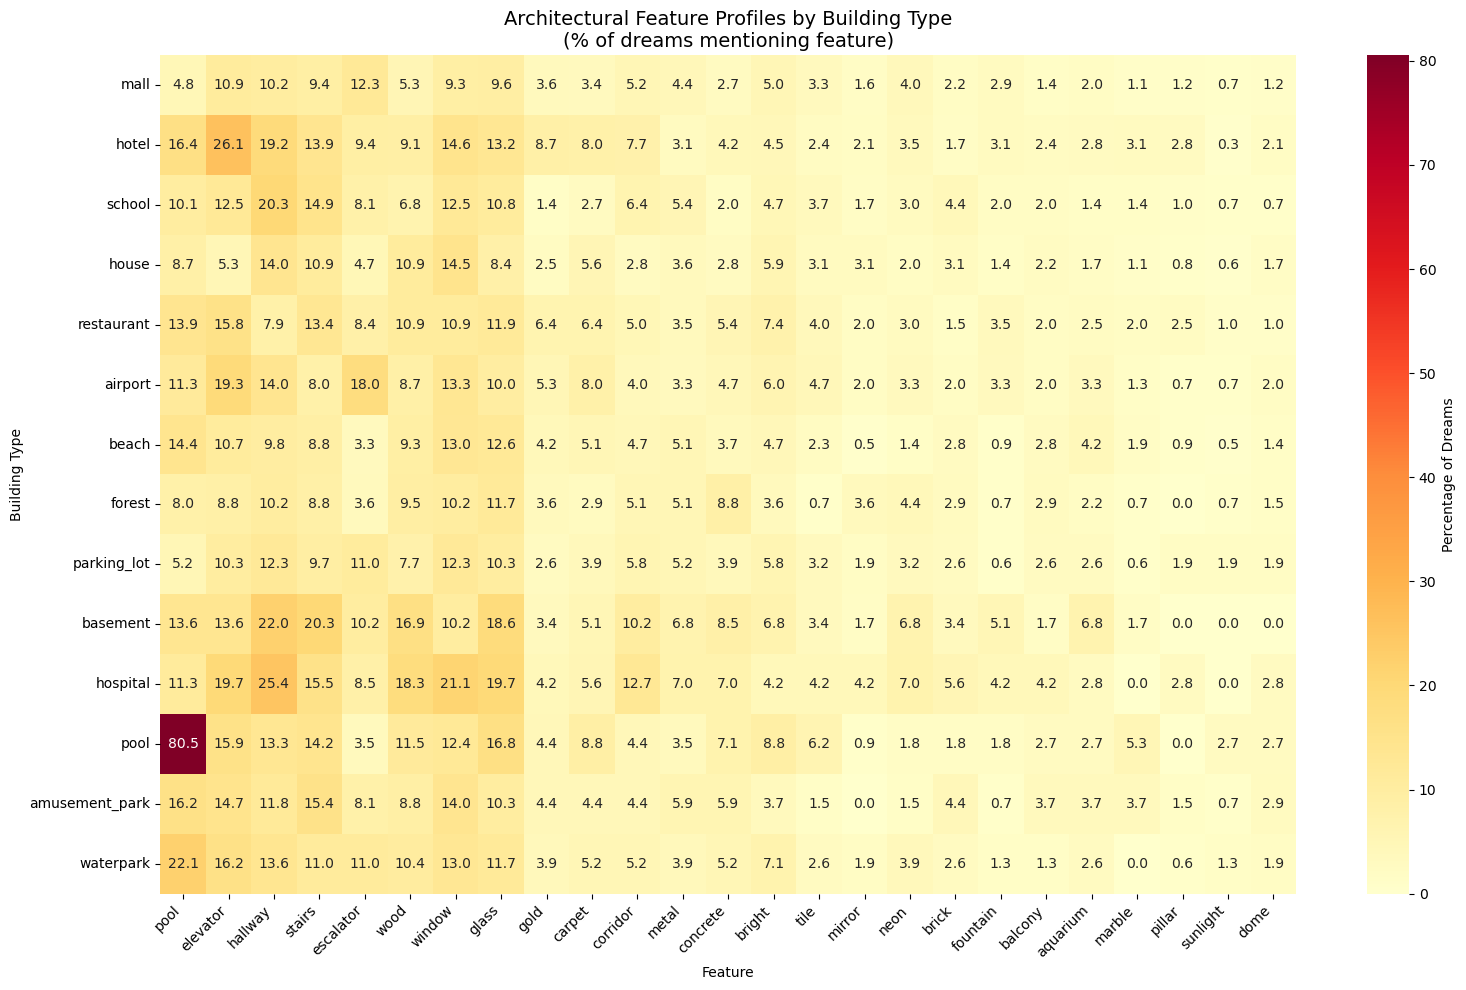


Interpretation: Different colors across rows indicate building types have DIFFERENT profiles.


In [21]:
# Heatmap visualization of feature profiles
import matplotlib.pyplot as plt
import seaborn as sns

# Select top building types and most variable features
top_buildings = ['mall', 'hotel', 'school', 'house', 'restaurant', 'airport', 
                 'beach', 'forest', 'parking_lot', 'basement', 'hospital', 
                 'pool', 'church', 'amusement_park', 'waterpark']
top_buildings = [b for b in top_buildings if b in df_profiles.index]

# Select features with highest variance
top_features = [f for f, _ in sorted_var[:25] if f in df_profiles.columns]

# Create subset
df_heatmap = df_profiles.loc[top_buildings, top_features]

# Plot
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(df_heatmap, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'Percentage of Dreams'})
ax.set_title('Architectural Feature Profiles by Building Type\n(% of dreams mentioning feature)', fontsize=14)
ax.set_xlabel('Feature')
ax.set_ylabel('Building Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nInterpretation: Different colors across rows indicate building types have DIFFERENT profiles.")

In [22]:
# Summary: Key distinctive features for each building type
print("=" * 80)
print("DISTINCTIVE FEATURE PROFILES BY BUILDING TYPE")
print("=" * 80)
print("\nFor each building type, showing features where it ranks HIGHEST or LOWEST:")

# Calculate rank for each building type on each feature
feature_cols = [c for c in df_profiles.columns if c != 'n_dreams']
ranks = df_profiles[feature_cols].rank(ascending=False)

for lt in ['mall', 'hotel', 'school', 'house', 'restaurant', 'airport', 
           'beach', 'forest', 'basement', 'hospital', 'church', 'pool', 
           'waterpark', 'parking_lot', 'cave', 'underground']:
    if lt not in df_profiles.index:
        continue
    
    n = building_profiles[lt]['n_dreams']
    print(f"\n{lt.upper()} (n={n})")
    print("-" * 50)
    
    # Features where this type ranks in top 3
    top_feats = []
    for feat in feature_cols:
        if ranks.loc[lt, feat] <= 3:
            val = df_profiles.loc[lt, feat]
            rank = int(ranks.loc[lt, feat])
            top_feats.append((feat, val, rank))
    
    if top_feats:
        print("  HIGH (top 3):")
        for feat, val, rank in sorted(top_feats, key=lambda x: x[2]):
            print(f"    #{rank}: {feat} = {val:.1f}%")
    
    # Features where this type ranks in bottom 3
    bottom_feats = []
    for feat in feature_cols:
        if ranks.loc[lt, feat] >= len(df_profiles) - 2:
            val = df_profiles.loc[lt, feat]
            rank = int(ranks.loc[lt, feat])
            bottom_feats.append((feat, val, rank))
    
    if bottom_feats:
        print("  LOW (bottom 3):")
        for feat, val, rank in sorted(bottom_feats, key=lambda x: -x[2]):
            print(f"    #{rank}: {feat} = {val:.1f}%")

DISTINCTIVE FEATURE PROFILES BY BUILDING TYPE

For each building type, showing features where it ranks HIGHEST or LOWEST:

MALL (n=972)
--------------------------------------------------
  LOW (bottom 3):
    #42: pool = 4.8%

HOTEL (n=287)
--------------------------------------------------
  HIGH (top 3):
    #2: elevator = 26.1%

SCHOOL (n=296)
--------------------------------------------------
  LOW (bottom 3):
    #42: dome = 0.7%

HOUSE (n=358)
--------------------------------------------------
  LOW (bottom 3):
    #43: elevator = 5.3%

RESTAURANT (n=202)
--------------------------------------------------

AIRPORT (n=150)
--------------------------------------------------

BEACH (n=215)
--------------------------------------------------
  LOW (bottom 3):
    #43: escalator = 3.3%
    #42: mirror = 0.5%

FOREST (n=137)
--------------------------------------------------
  LOW (bottom 3):
    #42: tile = 0.7%

BASEMENT (n=59)
--------------------------------------------------
  HIGH

In [23]:
# Metals breakdown: Which building types mention which metals?
print("=" * 80)
print("METAL CORRESPONDENCE ANALYSIS")
print("=" * 80)

metal_cols = ['gold', 'silver', 'brass', 'bronze', 'iron', 'copper', 'steel', 'chrome', 'metal']

# For each metal, which building types mention it most?
print("\nWhere each metal appears most frequently:")
print("-" * 60)

for metal in metal_cols:
    if metal not in df_profiles.columns:
        continue
    
    # Sort building types by this metal
    sorted_types = df_profiles[metal].sort_values(ascending=False)
    top_3 = sorted_types.head(5)
    
    if top_3.max() > 0:
        print(f"\n{metal.upper()}:")
        for lt, val in top_3.items():
            if val > 0:
                n = building_profiles[lt]['n_dreams']
                print(f"    {lt:<20} {val:>5.1f}%  (n={n})")

# Total metal mentions by building type
print("\n" + "=" * 80)
print("TOTAL METAL MENTIONS BY BUILDING TYPE (sorted)")
print("=" * 80)

df_profiles['total_metals'] = df_profiles[metal_cols].sum(axis=1)
metal_ranking = df_profiles['total_metals'].sort_values(ascending=False)

print(f"\n{'Building Type':<25} {'Total Metal %':>15} {'N Dreams':>10}")
print("-" * 55)
for lt in metal_ranking.head(20).index:
    total = metal_ranking[lt]
    n = building_profiles[lt]['n_dreams']
    print(f"{lt:<25} {total:>14.1f}% {n:>10}")

METAL CORRESPONDENCE ANALYSIS

Where each metal appears most frequently:
------------------------------------------------------------

GOLD:
    hotel_lobby           17.2%  (n=64)
    hotel_room            13.1%  (n=84)
    casino                11.9%  (n=67)
    underground            9.0%  (n=78)
    hotel                  8.7%  (n=287)

SILVER:
    warehouse              4.8%  (n=63)
    airplane               3.6%  (n=55)
    casino                 3.0%  (n=67)
    office                 2.6%  (n=78)
    underground            2.6%  (n=78)

BRASS:
    mansion                1.3%  (n=79)
    apartment              0.8%  (n=122)
    downtown               0.8%  (n=123)
    forest                 0.7%  (n=137)
    city_street            0.5%  (n=422)

BRONZE:
    suburb                 2.0%  (n=50)
    downtown               1.6%  (n=123)
    mall_theater           1.6%  (n=124)
    hotel_lobby            1.6%  (n=64)
    train_station          1.2%  (n=83)

IRON:
    restaurant_fast

In [24]:
# Final summary: Building type profiles as DataFrame for easy export
print("=" * 80)
print("BUILDING TYPE PROFILE SUMMARY (EXPORTABLE)")
print("=" * 80)

# Create summary with category-level totals
summary_data = []
for lt in building_profiles.keys():
    row = {
        'building_type': lt,
        'n_dreams': building_profiles[lt]['n_dreams'],
        'n_locations': building_profiles[lt]['n_locations'],
    }
    
    # Add category totals
    for cat, feats in FEATURE_CATEGORIES.items():
        total = sum(df_profiles.loc[lt, f] for f in feats if f in df_profiles.columns)
        row[cat] = round(total, 1)
    
    # Add individual metals
    for metal in ['gold', 'silver', 'iron', 'steel', 'metal']:
        if metal in df_profiles.columns:
            row[f'metal_{metal}'] = round(df_profiles.loc[lt, metal], 1)
    
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values('n_dreams', ascending=False)

# Display
print("\n" + df_summary.to_string(index=False))

# Save to CSV
output_path = project_root / 'output' / 'building_type_profiles.csv'
output_path.parent.mkdir(exist_ok=True)
df_summary.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

BUILDING TYPE PROFILE SUMMARY (EXPORTABLE)

       building_type  n_dreams  n_locations  TRANSPARENCY  WATER  VERTICAL_CIRC  OPEN_SPACE  LIGHT  REFLECTION  METALS  FLOORING  STRUCTURE  metal_gold  metal_silver  metal_iron  metal_steel  metal_metal
               other      1392         2924          21.0   11.5           27.4         3.3    8.5         2.3    11.1      21.6       21.5         3.4           1.0         0.4          0.6          4.7
                mall       972         1173          20.1   10.2           32.6         4.4   10.8         1.9    10.9      18.0       20.5         3.6           1.0         0.4          0.4          4.4
          mall_store       465          701          23.7   13.8           29.2         3.7   13.5         1.9    12.5      24.1       23.4         4.9           0.9         0.4          0.6          4.7
         city_street       422          532          21.6   11.6           23.9         2.1   10.7         1.7    10.7      17.8       19.0 

In [25]:
# Key observations (without premature conclusions)
print("""
======================================================================
PHASE 13b: BUILDING TYPE PROFILES - KEY OBSERVATIONS
======================================================================

METHODOLOGY:
- 44 building types analyzed
- Each building type filtered from structured data
- Raw dream text loaded via source_file property
- 41 features searched (architectural + metals)

OBSERVATION 1: Building types DO have different profiles
- The heatmap shows clear variation across building types
- Some features cluster in specific building types
- This is DESCRIPTIVE data, not yet CONFIRMATORY

OBSERVATION 2: Notable patterns (to be tested, not confirmed)
""")

# Find most distinctive patterns
for lt in ['pool', 'hotel', 'basement', 'hospital', 'forest', 'beach', 'mall']:
    if lt not in df_profiles.index:
        continue
    n = building_profiles[lt]['n_dreams']
    
    # Get top 3 features
    sorted_feats = df_profiles.loc[lt].drop('n_dreams', errors='ignore').sort_values(ascending=False)
    top3 = sorted_feats.head(3)
    
    print(f"  {lt.upper()} (n={n}):")
    for feat, val in top3.items():
        print(f"    - {feat}: {val:.1f}%")
    print()

print("""
OBSERVATION 3: Metal mentions are generally LOW
- Most metals < 5% across all building types
- 'metal' (generic) is more common than specific metals
- Gold/silver are rare (< 2% in most contexts)

OBSERVATION 4: Some expected patterns appear
- Pool/waterpark high in 'pool' feature (obvious)
- Hotel high in 'elevator' (makes sense)
- Basement high in 'stairs' (access pattern)

WHAT THIS DOES NOT SHOW:
- Whether these patterns CORRESPOND to spiritual meanings
- Whether the profiles are SIGNIFICANTLY different statistically
- Whether correspondential theory PREDICTS these patterns

NEXT STEPS FOR CONFIRMATION:
1. Pre-register predictions based on Swedenborgian theory
2. Test whether observed profiles match predictions
3. Use holdout data to validate
""")


PHASE 13b: BUILDING TYPE PROFILES - KEY OBSERVATIONS

METHODOLOGY:
- 44 building types analyzed
- Each building type filtered from structured data
- Raw dream text loaded via source_file property
- 41 features searched (architectural + metals)

OBSERVATION 1: Building types DO have different profiles
- The heatmap shows clear variation across building types
- Some features cluster in specific building types
- This is DESCRIPTIVE data, not yet CONFIRMATORY

OBSERVATION 2: Notable patterns (to be tested, not confirmed)

  POOL (n=113):
    - pool: 80.5%
    - glass: 16.8%
    - elevator: 15.9%

  HOTEL (n=287):
    - elevator: 26.1%
    - hallway: 19.2%
    - pool: 16.4%

  BASEMENT (n=59):
    - hallway: 22.0%
    - stairs: 20.3%
    - glass: 18.6%

  HOSPITAL (n=71):
    - hallway: 25.4%
    - window: 21.1%
    - elevator: 19.7%

  FOREST (n=137):
    - total_metals: 13.1%
    - glass: 11.7%
    - hallway: 10.2%

  BEACH (n=215):
    - pool: 14.4%
    - window: 13.0%
    - glass: 12.6